# Car Price Prediction using Machine Learning



## Import libraries



In [22]:
import re
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


from sklearn.tree import DecisionTreeRegressor

RANDOM_STATE = 42
CURRENT_YEAR = 2026
sns.set_theme(style='whitegrid', palette='deep')
pd.set_option('display.max_columns', 30)

## Load the data



In [23]:
dataset_path = Path('data/Car_details_v3.csv')
car_dataset = pd.read_csv(dataset_path)

print(f'Dataset shape: {car_dataset.shape}')
display(car_dataset.head())

Dataset shape: (8128, 13)


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


##  Initial exploration and quality checks


In [24]:
car_dataset.info()

missing_values = car_dataset.isna().sum().sort_values(ascending=False)
quality_summary = pd.DataFrame({
    'missing_values': missing_values,
    'missing_percent': (missing_values / len(car_dataset) * 100).round(2),
    'data_type': car_dataset.dtypes
})
display(quality_summary[quality_summary['missing_values'] > 0])
print(f'Duplicate rows: {car_dataset.duplicated().sum()}')

<class 'pandas.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   str    
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   str    
 5   seller_type    8128 non-null   str    
 6   transmission   8128 non-null   str    
 7   owner          8128 non-null   str    
 8   mileage        7907 non-null   str    
 9   engine         7907 non-null   str    
 10  max_power      7913 non-null   str    
 11  torque         7906 non-null   str    
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), str(9)
memory usage: 1.6 MB


,missing_values,missing_percent,data_type
engine,221,2.72,str
max_power,215,2.65,str
mileage,221,2.72,str
seats,221,2.72,float64
torque,222,2.73,str


Duplicate rows: 1202


##  Data cleaning and simple feature engineering



In [25]:
processed_data = car_dataset.drop_duplicates().copy()

# Extract the first number from specifications such as '23.4 kmpl' and '1248 CC'.
def extract_number(value):
    if pd.isna(value):
        return np.nan
    match = re.search(r'\d+\.?\d*', str(value))
    return float(match.group()) if match else np.nan

processed_data['mileage_kmpl'] = processed_data['mileage'].apply(extract_number)
processed_data['engine_cc'] = processed_data['engine'].apply(extract_number)
processed_data['max_power_bhp'] = processed_data['max_power'].apply(extract_number)
processed_data['car_age'] = CURRENT_YEAR - processed_data['year']
processed_data['brand'] = processed_data['name'].str.split().str[0]

# Median imputation is simple, robust, and keeps useful listings in the analysis.
for column_name in ['mileage_kmpl', 'engine_cc', 'max_power_bhp', 'seats']:
    processed_data[column_name] = processed_data[column_name].fillna(processed_data[column_name].median())

# Keep values that make sense for a listed car.
processed_data = processed_data[processed_data['selling_price'] > 0]
processed_data = processed_data[processed_data['car_age'].between(0, 35)]
processed_data = processed_data[processed_data['km_driven'] >= 0]

print(f'Rows after cleaning: {len(processed_data):,}')
display(processed_data[['selling_price', 'car_age', 'mileage_kmpl', 'engine_cc', 'max_power_bhp', 'brand']].head())

Rows after cleaning: 6,925


,selling_price,car_age,mileage_kmpl,engine_cc,max_power_bhp,brand
0,450000,12,23.40,1248.0,74.00,Maruti
1,370000,12,21.14,1498.0,103.52,Skoda
2,158000,20,17.70,1497.0,78.00,Honda
3,225000,16,23.00,1396.0,90.00,Hyundai
4,130000,19,16.10,1298.0,88.20,Maruti


## Exploratory data analysis



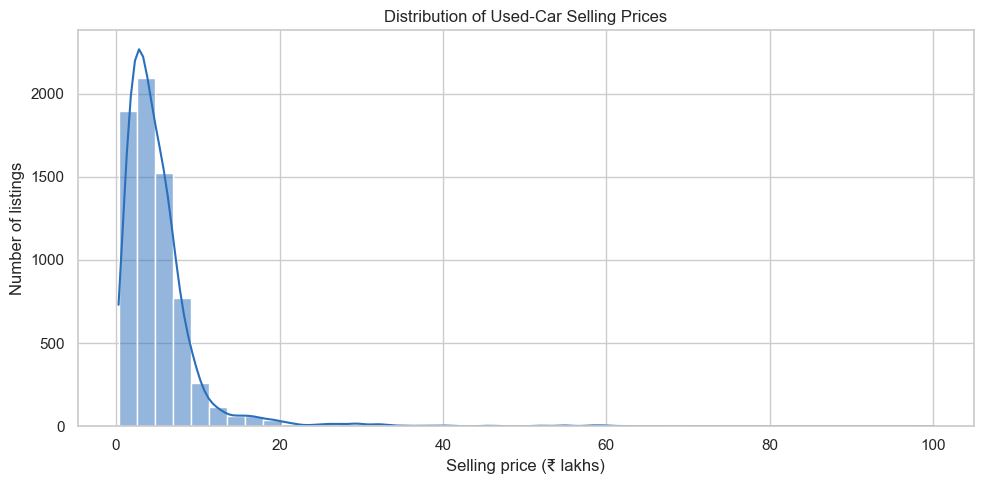

In [26]:
plt.figure(figsize=(10, 5))
sns.histplot(processed_data['selling_price'] / 100000, bins=45, kde=True, color='#2a6fbb')
plt.title('Distribution of Used-Car Selling Prices')
plt.xlabel('Selling price (₹ lakhs)')
plt.ylabel('Number of listings')
plt.tight_layout()
plt.show()

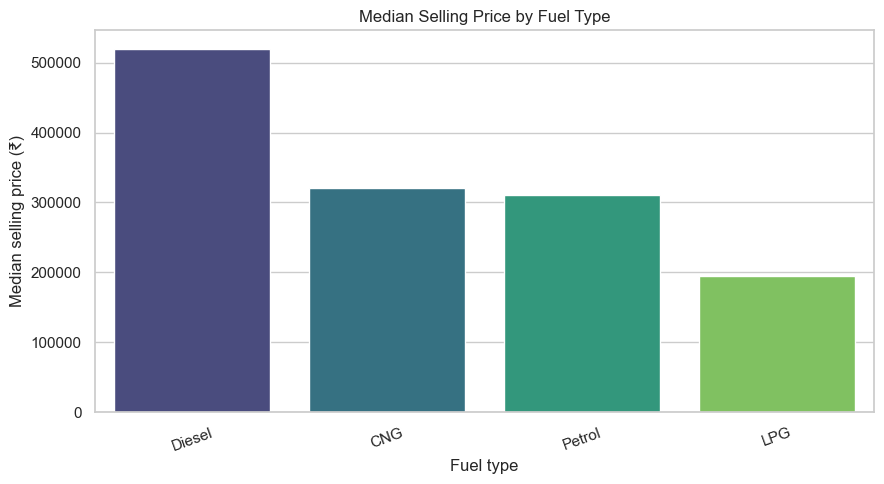

In [27]:
plt.figure(figsize=(9, 5))
price_by_fuel = processed_data.groupby('fuel', as_index=False)['selling_price'].median()
price_by_fuel = price_by_fuel.sort_values('selling_price', ascending=False)
sns.barplot(data=price_by_fuel, x='fuel', y='selling_price', hue='fuel', legend=False, palette='viridis')
plt.title('Median Selling Price by Fuel Type')
plt.xlabel('Fuel type')
plt.ylabel('Median selling price (₹)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

C:\Users\Vaishnavi\AppData\Local\Temp\ipykernel_27236\1941065020.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=brand_prices, x='brand', y='selling_price', order=top_brands, showfliers=False, palette='Set2')


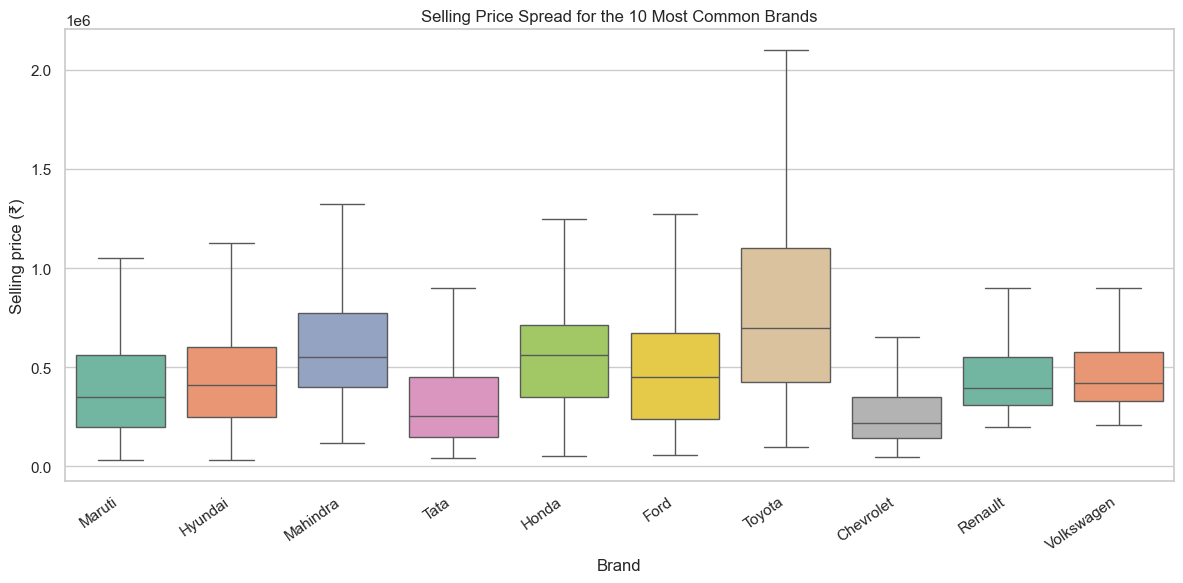

In [28]:
top_brands = processed_data['brand'].value_counts().head(10).index
brand_prices = processed_data[processed_data['brand'].isin(top_brands)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=brand_prices, x='brand', y='selling_price', order=top_brands, showfliers=False, palette='Set2')
plt.title('Selling Price Spread for the 10 Most Common Brands')
plt.xlabel('Brand')
plt.ylabel('Selling price (₹)')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

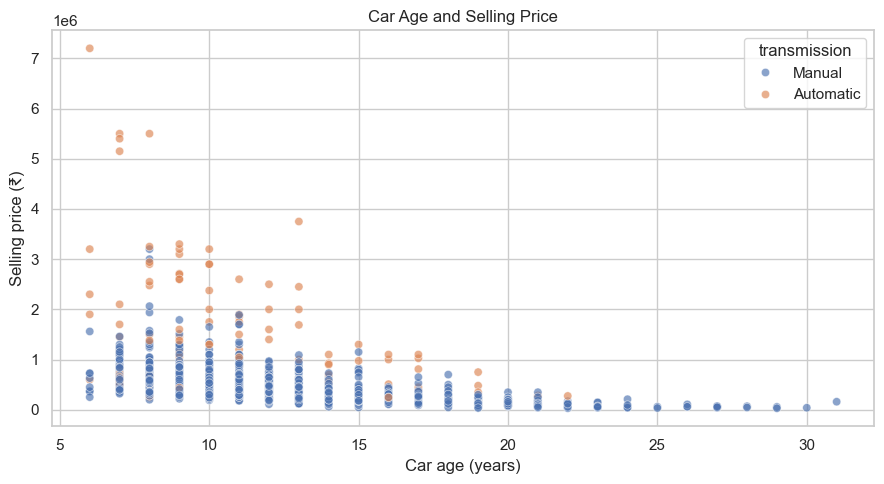

In [29]:
plt.figure(figsize=(9, 5))
sns.scatterplot(data=processed_data.sample(min(1500, len(processed_data)), random_state=RANDOM_STATE),
                x='car_age', y='selling_price', hue='transmission', alpha=0.65)
plt.title('Car Age and Selling Price')
plt.xlabel('Car age (years)')
plt.ylabel('Selling price (₹)')
plt.tight_layout()
plt.show()

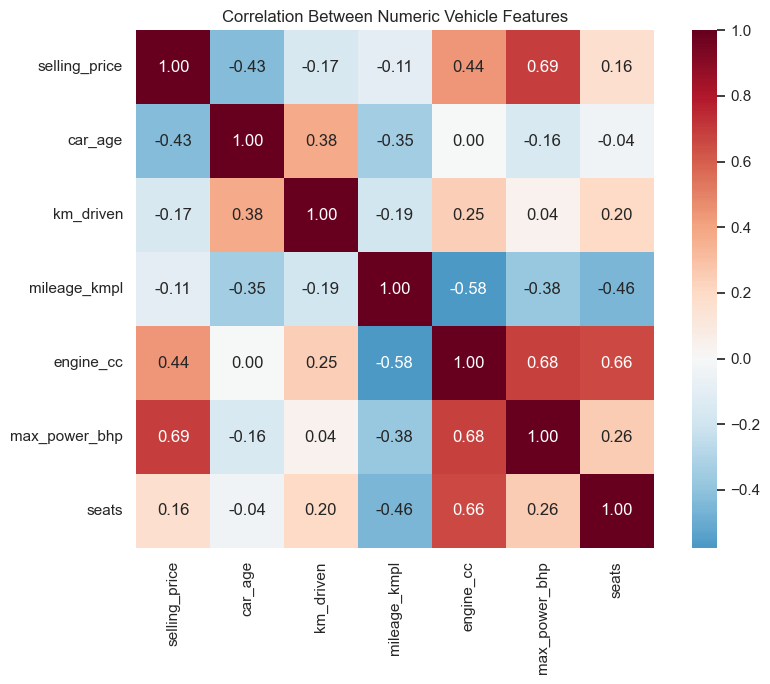

Correlation with selling price:
selling_price    1.000000
max_power_bhp    0.688837
engine_cc        0.444748
seats            0.163921
mileage_kmpl    -0.107374
km_driven       -0.165703
car_age         -0.434380
Name: selling_price, dtype: float64


In [30]:
## 7. Correlation analysis and feature selection
numeric_columns = ['selling_price', 'car_age', 'km_driven', 'mileage_kmpl', 'engine_cc', 'max_power_bhp', 'seats']
correlation_matrix = processed_data[numeric_columns].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True)
plt.title('Correlation Between Numeric Vehicle Features')
plt.tight_layout()
plt.show()

print('Correlation with selling price:')
print(correlation_matrix['selling_price'].sort_values(ascending=False))

## Prepare data and create a hold-out test set


In [31]:
selected_features = [
    'car_age', 'km_driven', 'mileage_kmpl', 'engine_cc', 'max_power_bhp', 'seats',
    'fuel', 'seller_type', 'transmission', 'owner', 'brand'
]
price_target = processed_data['selling_price']
feature_matrix = processed_data[selected_features].copy()

encoded_features = pd.get_dummies(feature_matrix, columns=['fuel', 'seller_type', 'transmission', 'owner', 'brand'], drop_first=True)
training_features, test_features, training_target, test_target = train_test_split(
    encoded_features, price_target, test_size=0.20, random_state=RANDOM_STATE
)

print(f'Training rows: {len(training_features):,}')
print(f'Test rows: {len(test_features):,}')
print(f'Model input columns: {training_features.shape[1]}')

Training rows: 5,540
Test rows: 1,385
Model input columns: 47


##  Build and compare regression models


In [32]:
# Scale only for the linear baseline.
scaler = StandardScaler()
scaled_training_features = scaler.fit_transform(training_features)
scaled_test_features = scaler.transform(test_features)

models_to_compare = {
    'Linear Regression': (LinearRegression(), scaled_training_features, scaled_test_features),
    'Decision Tree': (DecisionTreeRegressor(max_depth=14, min_samples_leaf=3, random_state=RANDOM_STATE), training_features, test_features),
    'Random Forest': (RandomForestRegressor(n_estimators=250, min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=-1), training_features, test_features)
}

evaluation_records = []
trained_models = {}

for model_name, (model, model_training_features, model_test_features) in models_to_compare.items():
    model.fit(model_training_features, training_target)
    predicted_prices = model.predict(model_test_features)
    trained_models[model_name] = model

    evaluation_records.append({
        'Model': model_name,
        'MAE (₹)': mean_absolute_error(test_target, predicted_prices),
        'RMSE (₹)': mean_squared_error(test_target, predicted_prices) ** 0.5,
        'R²': r2_score(test_target, predicted_prices)
    })

evaluation_results = pd.DataFrame(evaluation_records).sort_values('RMSE (₹)').reset_index(drop=True)
display(evaluation_results.style.format({'MAE (₹)': '₹{:,.0f}', 'RMSE (₹)': '₹{:,.0f}', 'R²': '{:.3f}'}))

,Model,MAE (₹),RMSE (₹),R²
0,Random Forest,"₹77,699","₹161,178",0.911
1,Decision Tree,"₹92,057","₹192,060",0.874
2,Linear Regression,"₹146,287","₹290,532",0.712


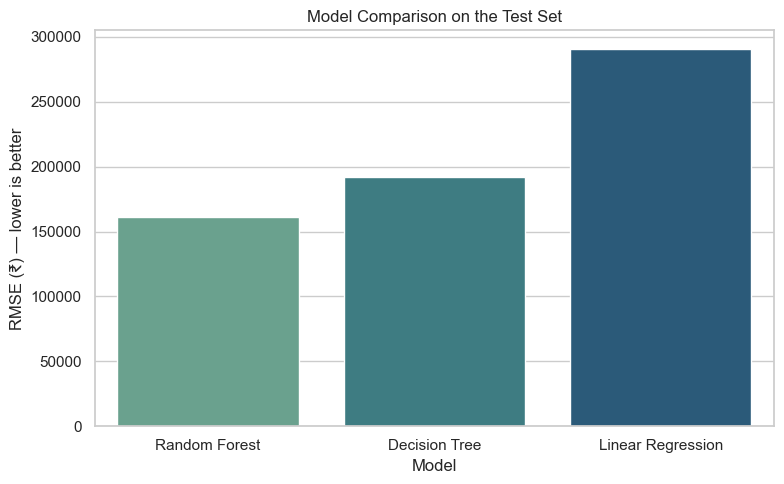

In [33]:
plt.figure(figsize=(8, 5))
sns.barplot(data=evaluation_results, x='Model', y='RMSE (₹)', hue='Model', legend=False, palette='crest')
plt.title('Model Comparison on the Test Set')
plt.xlabel('Model')
plt.ylabel('RMSE (₹) — lower is better')
plt.tight_layout()
plt.show()

# Evaluate the selected model 



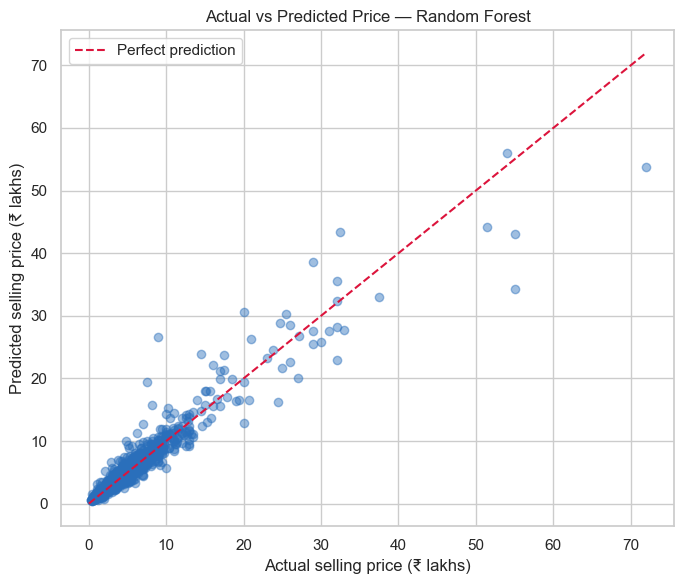

Selected model: Random Forest
Test MAE: ₹77,699
Test RMSE: ₹161,178
Test R²: 0.911


In [34]:
best_model_name = evaluation_results.loc[0, 'Model']
best_model = trained_models[best_model_name]

if best_model_name == 'Linear Regression':
    best_predictions = best_model.predict(scaled_test_features)
else:
    best_predictions = best_model.predict(test_features)

plt.figure(figsize=(7, 6))
plt.scatter(test_target / 100000, best_predictions / 100000, alpha=0.45, color='#2a6fbb')
plot_limit = max(test_target.max(), best_predictions.max()) / 100000
plt.plot([0, plot_limit], [0, plot_limit], '--', color='crimson', label='Perfect prediction')
plt.title(f'Actual vs Predicted Price — {best_model_name}')
plt.xlabel('Actual selling price (₹ lakhs)')
plt.ylabel('Predicted selling price (₹ lakhs)')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Selected model: {best_model_name}')
print(f'Test MAE: ₹{mean_absolute_error(test_target, best_predictions):,.0f}')
print(f'Test RMSE: ₹{mean_squared_error(test_target, best_predictions) ** 0.5:,.0f}')
print(f'Test R²: {r2_score(test_target, best_predictions):.3f}')

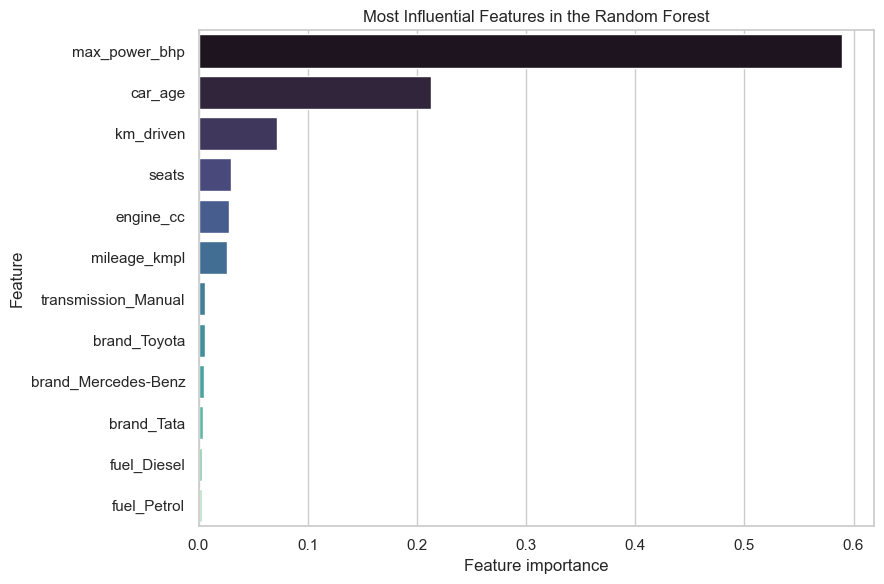

,feature,importance
4,max_power_bhp,0.589295
0,car_age,0.212891
1,km_driven,0.072362
5,seats,0.029958
3,engine_cc,0.027857
2,mileage_kmpl,0.025722
11,transmission_Manual,0.006364
44,brand_Toyota,0.005884
36,brand_Mercedes-Benz,0.004923
43,brand_Tata,0.004232


In [35]:
# Feature importance is shown for the Random Forest, whether or not it is the winning model.
forest_model = trained_models['Random Forest']
importance_table = pd.DataFrame({
    'feature': training_features.columns,
    'importance': forest_model.feature_importances_
}).sort_values('importance', ascending=False).head(12)

plt.figure(figsize=(9, 6))
sns.barplot(data=importance_table, y='feature', x='importance', hue='feature', legend=False, palette='mako')
plt.title('Most Influential Features in the Random Forest')
plt.xlabel('Feature importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()
display(importance_table)

In [36]:
Path('models').mkdir(exist_ok=True)
model_artifact = {
    'model_name': best_model_name,
    'model': best_model,
    'feature_columns': list(training_features.columns),
    'scaler': scaler if best_model_name == 'Linear Regression' else None,
    'created_for': 'CarDekho used-car price prediction project'
}
joblib.dump(model_artifact, 'models/car_price_model.pkl')
print('Saved: models/car_price_model.pkl')

Saved: models/car_price_model.pkl
